In [1]:
# ==========================================================
# STUDENT 3
# NOTEBOOK 06
# ROBERTA + XGBOOST EVALUATION
# ==========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import joblib

from sklearn.metrics import (

    classification_report,

    accuracy_score,

    balanced_accuracy_score,

    matthews_corrcoef,

    cohen_kappa_score,

    roc_auc_score,

    precision_recall_curve,

    roc_curve,

    auc,

    confusion_matrix,

    ConfusionMatrixDisplay

)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# CONFIGURATION
# ==========================================================

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

MODELS = PROJECT_ROOT / "models"

REPORTS = PROJECT_ROOT / "reports"

FIGURES = PROJECT_ROOT / "figures"

EMBEDDINGS = PROJECT_ROOT / "embeddings" / "roberta"

print("="*70)
print("ROBERTA + XGBOOST EVALUATION")
print("="*70)

ROBERTA + XGBOOST EVALUATION


In [3]:
# ==========================================================
# LOAD BEST MODEL
# ==========================================================

model = joblib.load(

    MODELS /

    "best_roberta_xgboost.pkl"

)

print("="*70)
print("BEST ROBERTA-XGBOOST MODEL LOADED")
print("="*70)

BEST ROBERTA-XGBOOST MODEL LOADED


In [4]:
# ==========================================================
# LOAD TEST EMBEDDINGS
# ==========================================================

X_test = np.load(

    EMBEDDINGS /

    "test_embeddings.npy"

)

y_test = np.load(

    EMBEDDINGS /

    "test_labels.npy"

)

print(X_test.shape)

print(y_test.shape)

(1000, 768)
(1000,)


In [5]:
# ==========================================================
# GENERATE PREDICTIONS
# ==========================================================

predictions = model.predict(

    X_test

)

probabilities = model.predict_proba(

    X_test

)[:,1]

print("="*70)
print("PREDICTIONS GENERATED")
print("="*70)

print("Predictions :", len(predictions))

print("Probabilities :", len(probabilities))

PREDICTIONS GENERATED
Predictions : 1000
Probabilities : 1000


In [6]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

report = classification_report(

    y_test,

    predictions,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv(

    REPORTS /

    "roberta_xgboost_classification_report.csv"

)

print("="*70)
print("CLASSIFICATION REPORT SAVED")
print("="*70)

,precision,recall,f1-score,support
0,0.994518,0.996703,0.995609,910.000
1,0.965909,0.944444,0.955056,90.000
accuracy,0.992000,0.992000,0.992000,0.992
macro avg,0.980213,0.970574,0.975333,1000.000
weighted avg,0.991943,0.992000,0.991959,1000.000


CLASSIFICATION REPORT SAVED


In [7]:
# ==========================================================
# PERFORMANCE SUMMARY
# ==========================================================

accuracy = accuracy_score(

    y_test,

    predictions

)

balanced_accuracy = balanced_accuracy_score(

    y_test,

    predictions

)

roc_auc = roc_auc_score(

    y_test,

    probabilities

)

precision, recall, _ = precision_recall_curve(

    y_test,

    probabilities

)

pr_auc = auc(

    recall,

    precision

)

mcc = matthews_corrcoef(

    y_test,

    predictions

)

kappa = cohen_kappa_score(

    y_test,

    predictions

)

performance_summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Balanced Accuracy",

        "ROC-AUC",

        "PR-AUC",

        "Matthews Correlation Coefficient",

        "Cohen's Kappa"

    ],

    "Value":[

        accuracy,

        balanced_accuracy,

        roc_auc,

        pr_auc,

        mcc,

        kappa

    ]

})

display(performance_summary)

performance_summary.to_csv(

    REPORTS /

    "roberta_xgboost_performance_summary.csv",

    index=False

)

print("="*70)
print("PERFORMANCE SUMMARY SAVED")
print("="*70)

,Metric,Value
0,Accuracy,0.992000
1,Balanced Accuracy,0.970574
2,ROC-AUC,0.997631
3,PR-AUC,0.983354
4,Matthews Correlation Coefficient,0.950738
5,Cohen's Kappa,0.950666


PERFORMANCE SUMMARY SAVED


,Predicted Ham,Predicted Spam
Actual Ham,907,3
Actual Spam,5,85


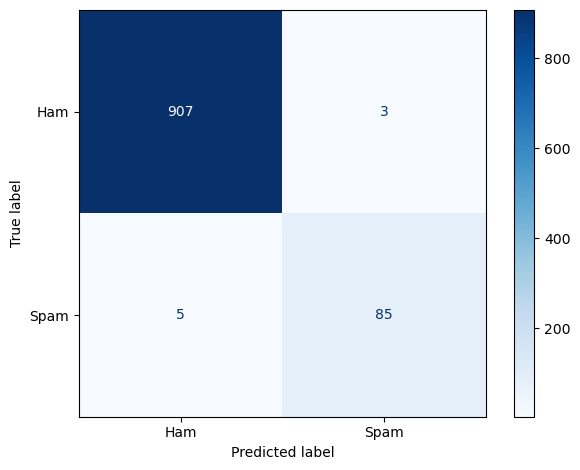

CONFUSION MATRIX SAVED


In [8]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(

    y_test,

    predictions

)

cm_df = pd.DataFrame(

    cm,

    index=["Actual Ham","Actual Spam"],

    columns=["Predicted Ham","Predicted Spam"]

)

display(cm_df)

cm_df.to_csv(

    REPORTS /

    "roberta_xgboost_confusion_matrix.csv"

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Ham","Spam"]

)

disp.plot(cmap="Blues")

plt.tight_layout()

plt.savefig(

    FIGURES /

    "roberta_xgboost_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("="*70)
print("CONFUSION MATRIX SAVED")
print("="*70)

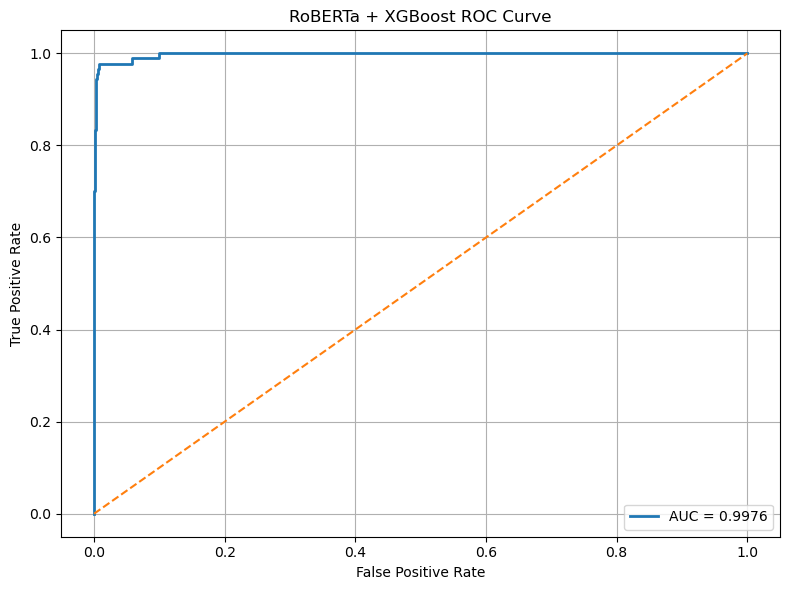

ROC CURVE SAVED


In [9]:
# ==========================================================
# ROC CURVE
# ==========================================================

fpr, tpr, _ = roc_curve(

    y_test,

    probabilities

)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("RoBERTa + XGBoost ROC Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    FIGURES /

    "roberta_xgboost_roc_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("="*70)
print("ROC CURVE SAVED")
print("="*70)

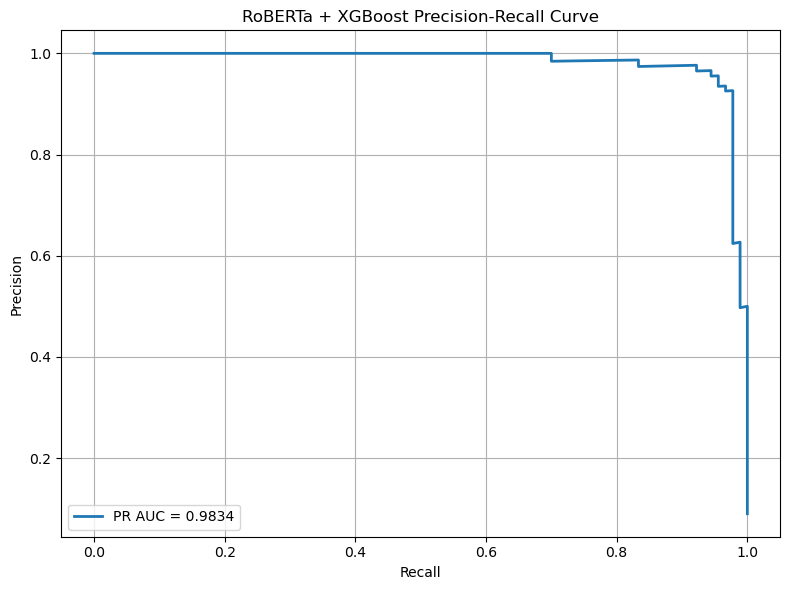

PRECISION-RECALL CURVE SAVED


In [10]:
# ==========================================================
# PRECISION RECALL CURVE
# ==========================================================

plt.figure(figsize=(8,6))

plt.plot(

    recall,

    precision,

    linewidth=2,

    label=f"PR AUC = {pr_auc:.4f}"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("RoBERTa + XGBoost Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    FIGURES /

    "roberta_xgboost_precision_recall_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("="*70)
print("PRECISION-RECALL CURVE SAVED")
print("="*70)

# RESULT AND CONCLUSION 
On the evaluated email spam/phishing dataset, replacing the Transformer classification head with an XGBoost classifier did not improve classification performance. The fine-tuned Transformer models consistently achieved superior accuracy and F1-score, suggesting that end-to-end optimization of the encoder and classification head is more effective than the investigated two-stage hybrid architecture.